In [ ]:
import numpy, pandas
import conntility

from scipy.spatial.distance import pdist, squareform
from scipy import sparse
from scipy.stats import percentileofscore
from matplotlib import pyplot as plt

fn = "peng_et_al_human_multi_patch_grp.h5"
G = conntility.ConnectivityGroup.from_h5(fn)

In [2]:
def configuration_model(mat, vert, direction="efferent"):
    if direction == "afferent":
        return configuration_model(mat.transpose(), vert).transpose()
    assert direction == "efferent"
    rows = []
    for i in range(mat.shape[0]):
        rows.append(numpy.random.choice(
            numpy.setdiff1d(numpy.arange(mat.shape[1]), [i]),
            mat[i].nnz, replace=False
        ))
    data = numpy.ones(mat.nnz)
    indices = numpy.hstack(rows)
    indptr = numpy.cumsum([0] + list(map(len, rows)))
    ret = sparse.csr_matrix((data, indices, indptr), shape=mat.shape)
    assert ret.nnz == mat.nnz
    return ret
    

In [3]:
coords = ["coordinate_1", "coordinate_2", "coordinate_3"]


def analysis_func2(m, v, direction="efferent"):
    m = numpy.array(m.todense().astype(bool))
    d = squareform(pdist(v[coords]))
    numpy.fill_diagonal(d, numpy.inf)
    nn_idx = numpy.argmin(d, axis=0)
    if direction == "efferent":
        m_nn = m[:, nn_idx]
    elif direction == "afferent":
        m_nn = m[nn_idx]
    else: raise ValueError()
    return pandas.DataFrame(
        {
            "is_connected": m.flatten(),
            "nn_connected": m_nn.flatten(),
            "distance": d.flatten()
        }
    )

analysis_recipe = {
    "analyses": {
        "morphology_effect2":{
            "source": analysis_func2,
            "kwargs": {"direction": "efferent"},
            "output": "DataFrame",
            "decorators":[
                {
                    "name": "control_by_randomization",
                    "args":[configuration_model],
                    "kwargs": {"only_mean": False, "n_randomizations": 1000, "direction": "efferent"}
                }
            ]
        }
    }
}
full_res = G.analyze(analysis_recipe=analysis_recipe)
res = full_res["morphology_effect2"]

res = pandas.concat(res.values, axis=0, keys=res.index)
res = res.loc[~numpy.isinf(res["distance"])].copy()
res

is_connected  nn_connected  \
matrix_type matrix_number Control    Instance                                  
er          0             data       0        1          False         False   
                                              2           True         False   
                                              3          False          True   
                                              4          False         False   
                                              5          False         False   
...                                                        ...           ...   
tr          53            randomized 999      58         False         False   
                                              59         False         False   
                                              60         False         False   
                                              61         False         False   
                                              62         False         False   

                                                    distance  
matrix_type matrix_number Control    Instance                 
er          0             data       0        1    71.925828  
                                              2    68.444331  
                                              3   113.181181  
                                              4   197.190832  
                                              5   240.777841  
...                                                      ...  
tr          53            randomized 999      58   97.140752  
                                              59  148.249908  
                                              60  133.626229  
                                              61   85.501149  
                                              62   53.569245  

[9125116 rows x 3 columns]

In [4]:
dbins = numpy.arange(0, 240 + 35, 35)
bin_names = [f"{int(a)}-{int(b)} um" for a, b in zip(dbins[:-1], dbins[1:])] + [f"> {int(dbins[-1])} um"]
bin_names = numpy.array(bin_names)
for col in ["distance"]:
    outcol = "binned_" + col
    res[outcol] = bin_names[numpy.digitize(res[col], bins=dbins) - 1]


/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/2163669367.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(con_probs.loc[("data", False)].transpose(), color="black", marker="o", ms=4, label="Data, NN unconnected")
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/2163669367.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(con_probs.loc[("data", True)].transpose(), color="green", marker="o", ms=4, label="Data, NN connected")
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/2163669367.py:20: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(con_probs.loc[("randomized", False)].transpose()[rnd], color="grey", ls="--", lw=0.25)
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/2163669367.py:21: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(con_probs.loc[("randomized", False)].mean(

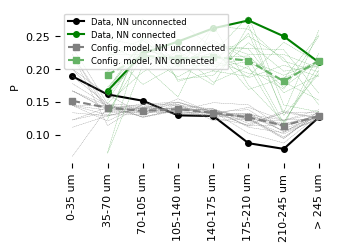

In [ ]:
min_smpl = 25
p_thresh = 0.05

con_probs = res.groupby(["Control", "Instance", "binned_distance", "nn_connected"])["is_connected"].mean()
smpl_count = res.groupby(["Control", "Instance", "binned_distance", "nn_connected"])["is_connected"].count()
con_probs[smpl_count < min_smpl] = numpy.nan
con_probs = con_probs.unstack("binned_distance")[bin_names].reorder_levels([0, 2, 1])

# percs = con_probs.stack().groupby(["nn_connected", "binned_distance"]).apply(lambda s: percentileofscore(s["randomized"], s["data"].values[0]))
# is_sig_elevated = percs[True].reindex(bin_names) > (100.0 - 100 * p_thresh)
# is_sig_decreased = percs[False].reindex(bin_names) < (100 * p_thresh)

fig = plt.figure(figsize=(3.5, 2.0))
ax = fig.gca()

ax.plot(con_probs.loc[("data", False)].transpose(), color="black", marker="o", ms=4, label="Data, NN unconnected")
ax.plot(con_probs.loc[("data", True)].transpose(), color="green", marker="o", ms=4, label="Data, NN connected")

#rnd = numpy.random.choice(len(con_probs.loc[("randomized", True)]), 20, replace=False)
ax.plot(con_probs.loc[("randomized", False)].transpose()[rnd], color="grey", ls="--", lw=0.25)
ax.plot(con_probs.loc[("randomized", False)].mean(), color="grey", ls="--", lw=1.5, marker="s", ms=4, label="Config. model, NN unconnected")
ax.plot(con_probs.loc[("randomized", True)].transpose()[rnd], color=[0.4, 0.7, 0.4], ls="--", lw=0.25)
ax.plot(con_probs.loc[("randomized", True)].mean(), color=[0.4, 0.7, 0.4], ls="--", lw=1.5, marker="s", ms=4, label="Config. model, NN connected")

# ylim = ax.get_ylim(); ax.set_ylim(ylim)
# top = 0.95 * ylim[1] + 0.05 * ylim[0]
# bottom = 0.05 * ylim[1] + 0.95 * ylim[0]
# for i, b in enumerate(is_sig_elevated.values):
#     if b:
#         ax.plot(i, top, marker="*", ms=5, color="red")
# for i, b in enumerate(is_sig_decreased.values):
#     if b:
#         ax.plot(i, bottom, marker="*", ms=5, color="blue")

plt.legend(fontsize=6)
ax.set_frame_on(False)
_ = ax.set_xticklabels(bin_names, rotation="vertical", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_ylabel("P", fontsize=8)

fig.savefig("Peng1.pdf")

/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/1175505210.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/1175505210.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/1175505210.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_38734/1175505210.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixed

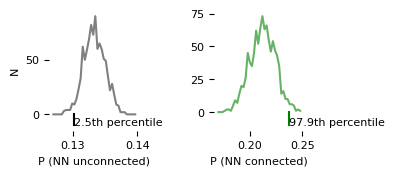

In [ ]:
mean_vals = res.groupby(["Control", "Instance", "nn_connected"])["is_connected"].mean().unstack("nn_connected")

fig = plt.figure(figsize=(3, 1.5))

ax = fig.add_axes([0.1, 0.1, 0.3, 0.8])
bins = numpy.linspace(0.127, 0.14, 41)

h = numpy.histogram(mean_vals.loc["randomized", False], bins=bins)[0]
ax.plot(bins[:-1], h, color="grey")
v = mean_vals.loc["data", False].values[0]
perc = percentileofscore(mean_vals.loc["randomized", False], v)
ax.plot([v, v], [-10, 0], color="black")
ax.text(v, -10, f"{perc}th percentile", fontsize=8)
ax.set_frame_on(False)
ax.set_xlabel("P (NN unconnected)", fontsize=8)
ax.set_ylabel("N", fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

ax = fig.add_axes([0.65, 0.1, 0.3, 0.8])
bins = numpy.linspace(0.17, 0.25, 41)

h = numpy.histogram(mean_vals.loc["randomized", True], bins=bins)[0]
ax.plot(bins[:-1], h, color=[0.4, 0.7, 0.4])
v = mean_vals.loc["data", True]
perc = percentileofscore(mean_vals.loc["randomized", True], v[0])
ax.plot([v[0], v[0]], [-10, 0], color="green")
ax.text(v[0], -10, f"{perc}th percentile", fontsize=8)
ax.set_frame_on(False)
ax.set_xlabel("P (NN connected)", fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

fig.savefig("Peng2.pdf")